# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle as pk
import os
import matplotlib.pyplot as plt
import json
from brokenaxes import brokenaxes
from tqdm import tqdm
import scipy.stats
import statsmodels.api as sm
from sklearn.metrics import cohen_kappa_score
pd.set_option('display.max_columns', None)
pd.set_option('future.no_silent_downcasting', True)
plt.rcParams.update({
    "axes.facecolor": "white",                      
    "axes.edgecolor": "black",                      
    "patch.facecolor": "lightcoral",
    "text.usetex": False,                           
    "font.family": "sans-serif",                    
    "axes.spines.top": False,                       
    "axes.spines.right": False,                     
    "axes.labelsize": 16,                           
    "xtick.labelsize": 14,                          
    "ytick.labelsize": 14,                          
    "axes.titlesize": 18,                           
    "figure.dpi": 300,                              
})

# Globals

In [2]:
num_features = 138
base_path = "../../"
os.makedirs(base_path + "plots/Figure2/", exist_ok=True)

# Load Data

In [3]:
data = pd.read_csv(base_path + "csvs/hills.csv")
data = data[~data["response"].isin(["mammal", "bacterium", "unicorn", "woollymammoth"])].reset_index(drop=True)
data["previous_response"] = data.groupby("pid")["response"].shift(1)
data["order"] = data.groupby("pid").cumcount() + 1
data = data.drop(columns=["fpatchnum", "fpatchitem", "fitemsfromend", "flastitem",  "meanirt", "catitem"])

# Get features

In [4]:
def get_featuredf(llm_name):
    featuredict = pk.load(open(base_path + f"files/features_{llm_name}.pk", "rb"))
    featuredf = pd.DataFrame.from_dict(featuredict, orient='index')
    featuredf = featuredf.replace({True: 1, False: 0, 'True': 1, 'True.': 1, 'TRUE': 1, 'true': 1, 'true.': 1, 'True.': 1, 'False': 0, 'False.': 0, 'false': 0, 'false.': 0, 'False.': 0})
    featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]
    return featuredf.astype(int), featuredf.columns.tolist()

vf_featuredf, vf_featurecols = get_featuredf("gpt41")
vf_featuredf = vf_featuredf.loc[vf_featuredf.index.isin(data["response"])]
vf_featuredf2, vf_featurecols2 = get_featuredf("gpt4omini")
vf_featuredf2 = vf_featuredf2.loc[vf_featuredf2.index.isin(data["response"])]
vf_featuredf3, vf_featurecols3 = get_featuredf("llama")
vf_featuredf3 = vf_featuredf3.loc[vf_featuredf3.index.isin(data["response"])]

/tmp/ipykernel_2089311/455247182.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]
/tmp/ipykernel_2089311/455247182.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]
/tmp/ipykernel_2089311/455247182.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  featuredf = featuredf[featuredf.applymap(lambda x: isinstance(x, int)).all(axis=1)]


# Analyse Feature Quality

In [5]:
common_index = vf_featuredf.index.intersection(vf_featuredf2.index).intersection(vf_featuredf3.index)
common_columns = vf_featuredf.columns.intersection(vf_featuredf2.columns).intersection(vf_featuredf3.columns)
vf_featuredf_aligned = vf_featuredf.loc[common_index, common_columns]
vf_featuredf2_aligned = vf_featuredf2.loc[common_index, common_columns]
vf_featuredf3_aligned = vf_featuredf3.loc[common_index, common_columns]

agree_12 = (vf_featuredf_aligned == vf_featuredf2_aligned).sum().sum()
agree_13 = (vf_featuredf_aligned == vf_featuredf3_aligned).sum().sum()
total_entries = vf_featuredf_aligned.size
pct_12 = agree_12 / total_entries
pct_13 = agree_13 / total_entries
print("Feature matching between gpt4.1 and gpt4omini:", pct_12)
print("Feature matching between gpt4.1 and llama:", pct_13)
kappa_12 = cohen_kappa_score(vf_featuredf_aligned.values.ravel(), vf_featuredf2_aligned.values.ravel())
kappa_13 = cohen_kappa_score(vf_featuredf_aligned.values.ravel(), vf_featuredf3_aligned.values.ravel())
print("Cohen's Kappa agreement between gpt4.1 and gpt4omini:", kappa_12)
print("Cohen's Kappa agreement between gpt4.1 and llama:", kappa_13)

# Names of features and animals that had the most disagreements across LLMs
diff_counts_2 = (vf_featuredf_aligned != vf_featuredf2_aligned).sum().to_dict()
diff_counts_3 = (vf_featuredf_aligned != vf_featuredf3_aligned).sum().to_dict()
top10_2 = dict(sorted(diff_counts_2.items(), key=lambda x: x[1], reverse=True)[:10])
top10_3 = dict(sorted(diff_counts_3.items(), key=lambda x: x[1], reverse=True)[:10])
intersection = set(top10_2.keys()) & set(top10_3.keys())
print("Features that had the most disagreements across LLMs:", intersection)
diff_counts_2 = (vf_featuredf_aligned != vf_featuredf2_aligned).sum(axis=1).to_dict()
diff_counts_3 = (vf_featuredf_aligned != vf_featuredf3_aligned).sum(axis=1).to_dict()
top10_2 = dict(sorted(diff_counts_2.items(), key=lambda x: x[1], reverse=True)[:10])
top10_3 = dict(sorted(diff_counts_3.items(), key=lambda x: x[1], reverse=True)[:10])
intersection = set(top10_2.keys()) & set(top10_3.keys())
print("Animals that had the most disagreements across LLMs:", intersection)

Feature matching between gpt4.1 and gpt4omini: 0.8892284834978245
Feature matching between gpt4.1 and llama: 0.7973469171176908
Cohen's Kappa agreement between gpt4.1 and gpt4omini: 0.7523569256994543
Cohen's Kappa agreement between gpt4.1 and llama: 0.5377917212245142
Features that had the most disagreements across LLMs: {'feature_Is smaller in size compared to other animals', 'feature_Exhibits altruistic behavior', 'feature_Has distinct seasonal breeding cycles', 'feature_Is average size compared to other animals'}
Animals that had the most disagreements across LLMs: {'bug', 'tick', 'ant', 'doe'}


# Add features to responses

In [6]:
def add_features_to_responsedf(df):
    featuredict = vf_featuredf.to_dict(orient='index')
    mapped_features = df['response'].map(featuredict)
    mapped_features = mapped_features.apply(lambda x: x if isinstance(x, dict) else {})
    fc = pd.DataFrame(mapped_features.tolist())
    df = pd.concat([df, fc], axis=1)
    df = df.replace({'True': 1, 'True.': 1, 'False': 0, 'False.': 0})
    dropped_rows = df[df[vf_featurecols].isna().any(axis=1)]
    df = df.dropna(subset=vf_featurecols)
    for col in vf_featurecols:
        df[col] = df[col].astype(int)
    return df, dropped_rows

data, dropped_rows = add_features_to_responsedf(data)
feature_cols = [col for col in data.columns if col.startswith('feature_')]

# Figure 2

## Figure 2A

In [7]:
def get_num_features_same(df, featurecols):
    df['num_features_same'] = None
    df = df.groupby('pid', group_keys=False).apply(calculate_num_features_same, featurecols = featurecols)
    return df

def calculate_num_features_same(group, featurecols):
    original_index = group.index
    group = group.reset_index(drop=True)
    num_features_same = [np.nan]  # Initialize with nan for the first row
    
    for i in range(1, len(group)):
        row1 = group.loc[i - 1, featurecols]
        row2 = group.loc[i, featurecols]
        
        # Check for NaN values
        if row1.isna().any() or row2.isna().any():
            num_features_same.append(np.nan)
        else:
            consecutive_1s = ((row1 == 1) & (row2 == 1)) | ((row1 == 0) & (row2 == 0))
            # consecutive_1s = ((row1 == 1) & (row2 == 1))
            num_features_same.append(consecutive_1s.sum())
    
    group['num_features_same'] = num_features_same
    group.index = original_index  # restore original unique index (avoid leaking per-group reset index)
    return group

data = get_num_features_same(data, vf_featurecols)

/tmp/ipykernel_2089311/3928035873.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['num_features_same'] = None
/tmp/ipykernel_2089311/3928035873.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_num_features_same, featurecols = featurecols)


In [8]:
datacopy = data.copy()
data = data.dropna()

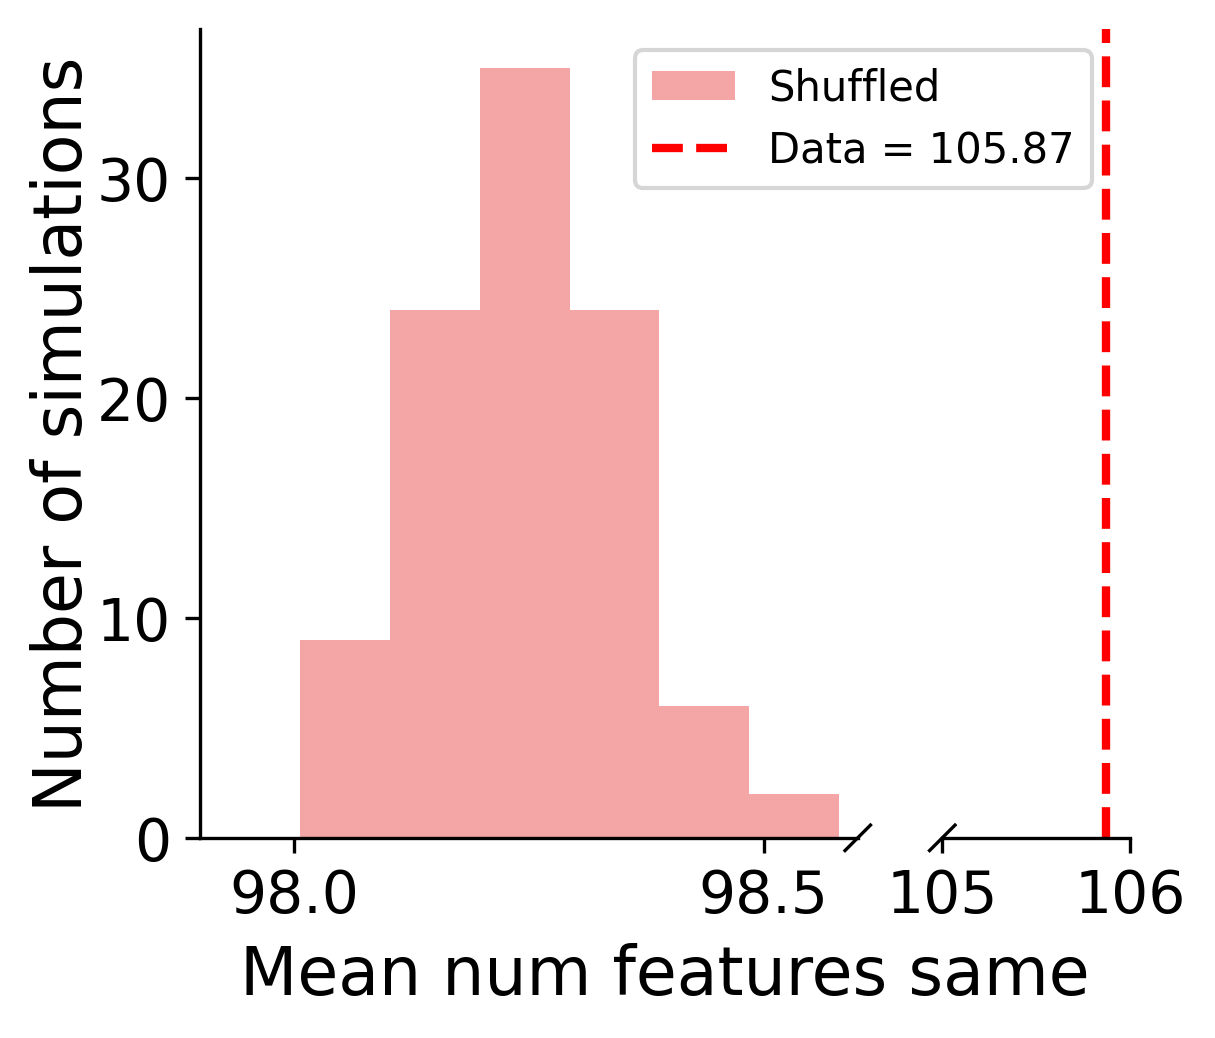

In [9]:
# shuffle within each pid - TAKES SUPER LONG, SERIALIZE
try:
    means = pk.load(open(base_path + "files/shuffled_data_meanHS.pk", "rb"))
except:
    means = []
    for _ in tqdm(range(100)):
        shuffled_data2 = data.groupby("pid", group_keys=False).apply(lambda x: x.sample(frac=1).reset_index(drop=True))
        shuffled_data2 = get_num_features_same(shuffled_data2, vf_featurecols)
        means.append(np.mean(shuffled_data2[["num_features_same", "pid"]].groupby("pid").mean()["num_features_same"].values))
    pk.dump(means, open(base_path + "files/shuffled_data_meanHS.pk", "wb"))

plt.rcParams['figure.dpi'] = 300
plt.figure(figsize=(4, 3.5))
data_mean = np.mean(data[["num_features_same", "pid"]].groupby("pid").mean()["num_features_same"].values)
bax = brokenaxes(xlims=((97.9, 98.6), (data_mean - 0.1, data_mean + 0.1)),hspace=0.05)
bax.hist(means, bins=6, color='lightcoral', label="Shuffled", alpha=0.7)
bax.axvline(data_mean, color='red', linestyle='--', linewidth=2, label=f'Data = {data_mean:.2f}')
bax.set_xlabel("Mean num features same", labelpad=25)
bax.set_ylabel("Number of simulations", labelpad=25)
bax.axs[0].set_xticks([98.0, 98.5])
bax.axs[1].set_xticks([105, 106])
bax.legend(loc='upper right', bbox_to_anchor=(0.981, 1))
plt.savefig(base_path + "plots/Figure2/2A.pdf", bbox_inches='tight')
plt.show()

## Figure 2B

In [10]:
def get_num_features_same(df, featurecols, nback):
    df[f'num_features_same_{nback}back'] = np.nan  # Initialize the column with NaN
    df = df.groupby('pid', group_keys=False).apply(calculate_num_features_same, featurecols=featurecols, nback=nback)
    return df

def calculate_num_features_same(group, featurecols, nback):
    original_index = group.index
    group = group.reset_index(drop=True)
    
    num_features_same = np.full(len(group), np.nan)  # Initialize with NaN
    
    for i in range(nback, len(group)):
        row1 = group.loc[i - nback, featurecols]
        row2 = group.loc[i, featurecols]

        # Check for NaN values
        if row1.isna().any() or row2.isna().any():
            num_features_same[i] = np.nan
        else:
            consecutive_1s = ((row1 == 1) & (row2 == 1)) | ((row1 == 0) & (row2 == 0))
            num_features_same[i] = consecutive_1s.sum()
    
    group[f'num_features_same_{nback}back'] = num_features_same  # Assign correctly
    group.index = original_index  # restore original unique index (avoid leaking per-group reset index)
    return group

data = get_num_features_same(data, vf_featurecols, 2)
data = get_num_features_same(data, vf_featurecols, 3)
data = get_num_features_same(data, vf_featurecols, 4)
data = get_num_features_same(data, vf_featurecols, 5)

/tmp/ipykernel_2089311/3354839492.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_num_features_same, featurecols=featurecols, nback=nback)
/tmp/ipykernel_2089311/3354839492.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pid', group_keys=False).apply(calculate_num_features_same, featurecols=featurecols, nback=nback)
/tmp/ipyke

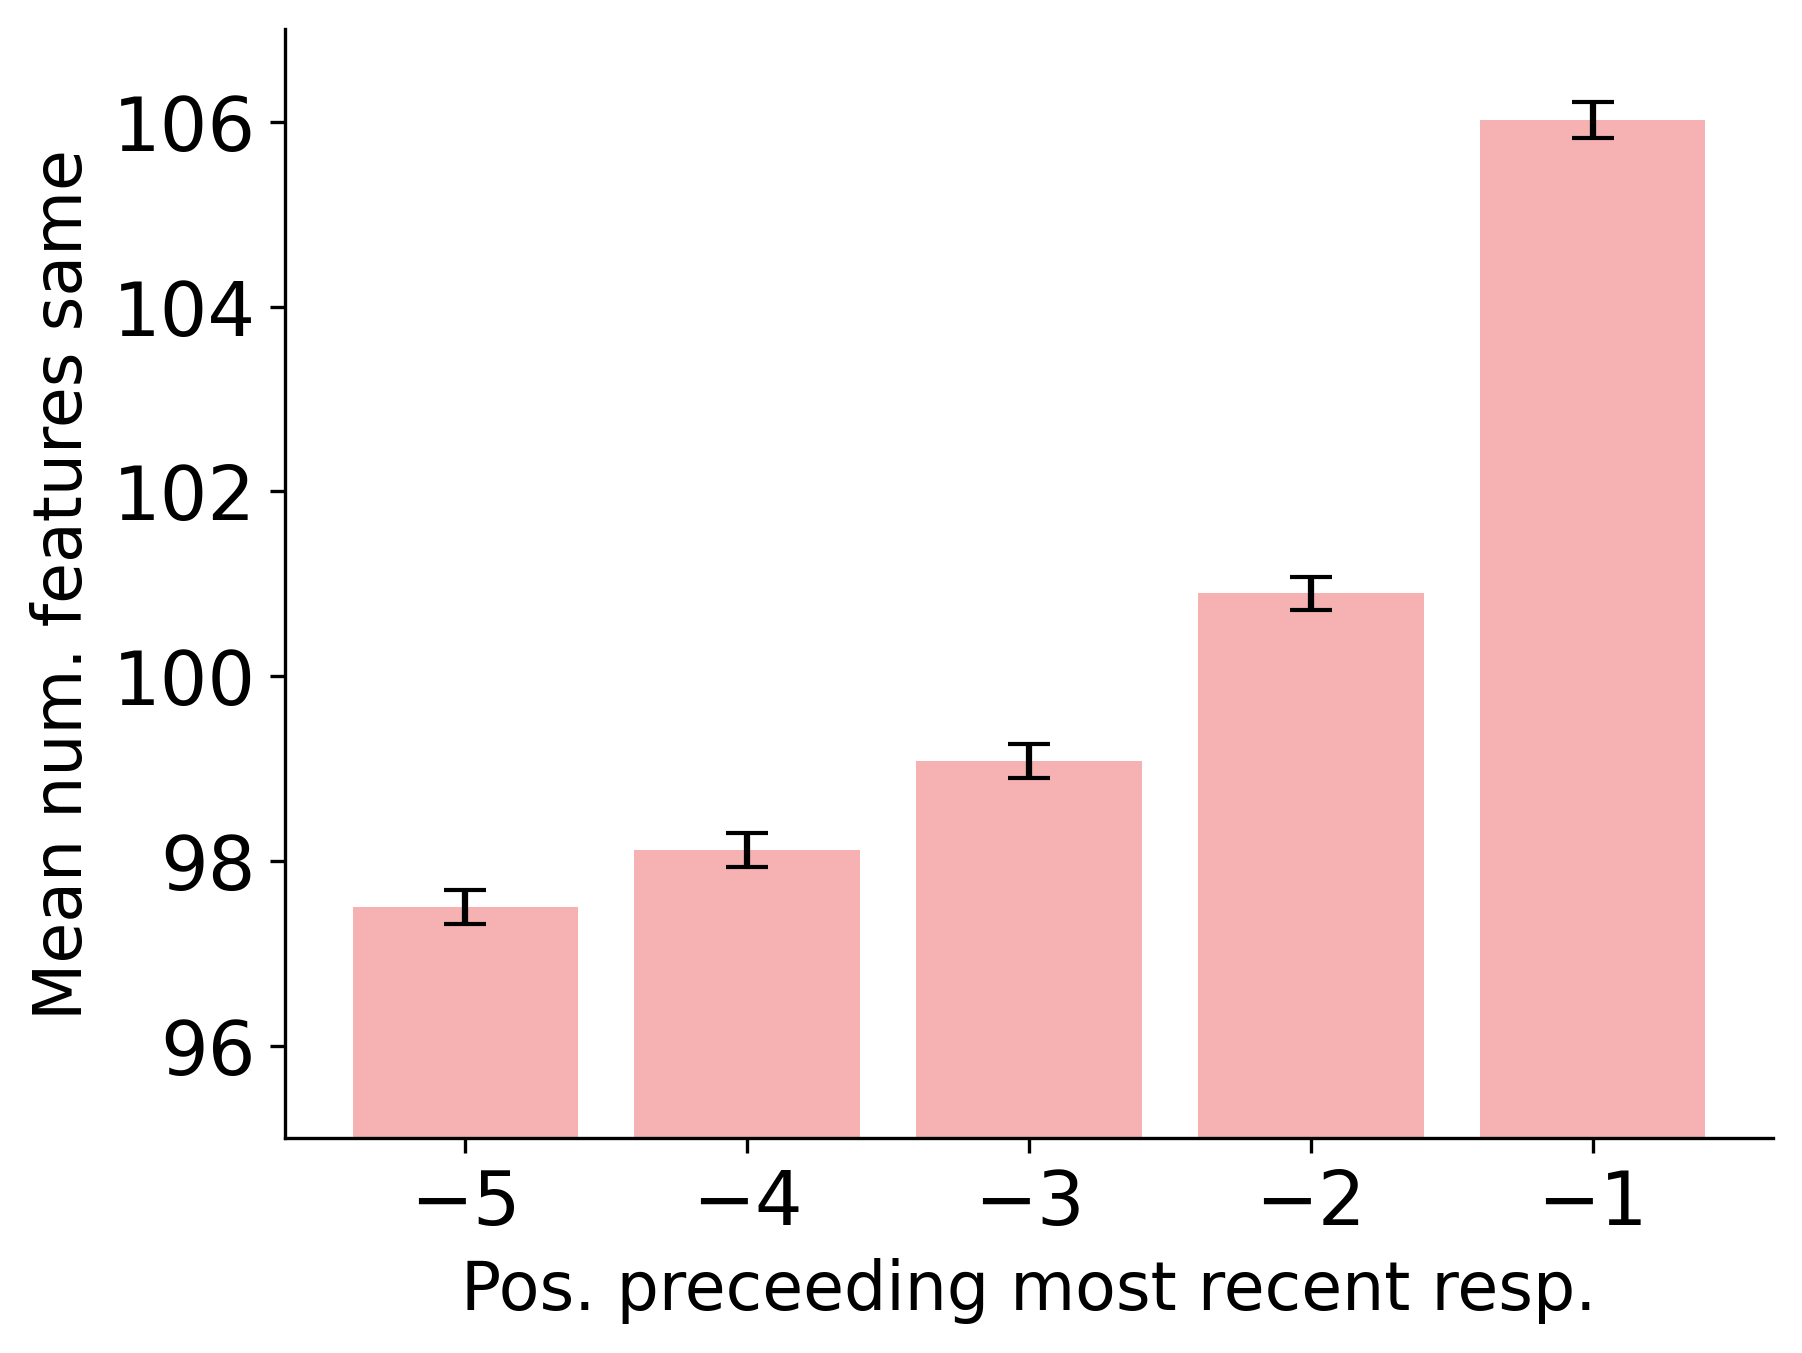

In [11]:
# Calculate means and standard errors
means = [
    np.mean(data["num_features_same_5back"]),
    np.mean(data["num_features_same_4back"]),
    np.mean(data["num_features_same_3back"]),
    np.mean(data["num_features_same_2back"]),
    np.mean(data["num_features_same"])
]

std_errors = [
    np.std(data["num_features_same_5back"], ddof=1) / np.sqrt(len(data["num_features_same_5back"].dropna())),
    np.std(data["num_features_same_4back"], ddof=1) / np.sqrt(len(data["num_features_same_4back"].dropna())),
    np.std(data["num_features_same_3back"], ddof=1) / np.sqrt(len(data["num_features_same_3back"].dropna())),
    np.std(data["num_features_same_2back"], ddof=1) / np.sqrt(len(data["num_features_same_2back"].dropna())),
    np.std(data["num_features_same"], ddof=1) / np.sqrt(len(data["num_features_same"].dropna()))
]

x_labels = [-5, -4, -3, -2, -1]

plt.bar(x_labels, means, yerr=std_errors, capsize=5, alpha=0.6, color='lightcoral')
plt.xlabel("Pos. preceeding most recent resp.")
plt.ylabel("Mean num. features same")
plt.ylim(95, 107)
plt.xticks(x_labels, fontsize=18)
plt.yticks(fontsize=18)
plt.savefig(base_path + "plots/Figure2/2B.pdf", bbox_inches="tight")

## Figure 2C

In [12]:
data["sum_features"] = data[vf_featurecols].sum(axis=1)
data["logRT"] = np.log(data["RT"] + 0.001)
data = data[data["logRT"] > -1.6]   # removes RT < 200 ms

/tmp/ipykernel_2089311/1816929588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = data.groupby("bin")["logRT"].agg(['mean', 'sem']).reset_index()


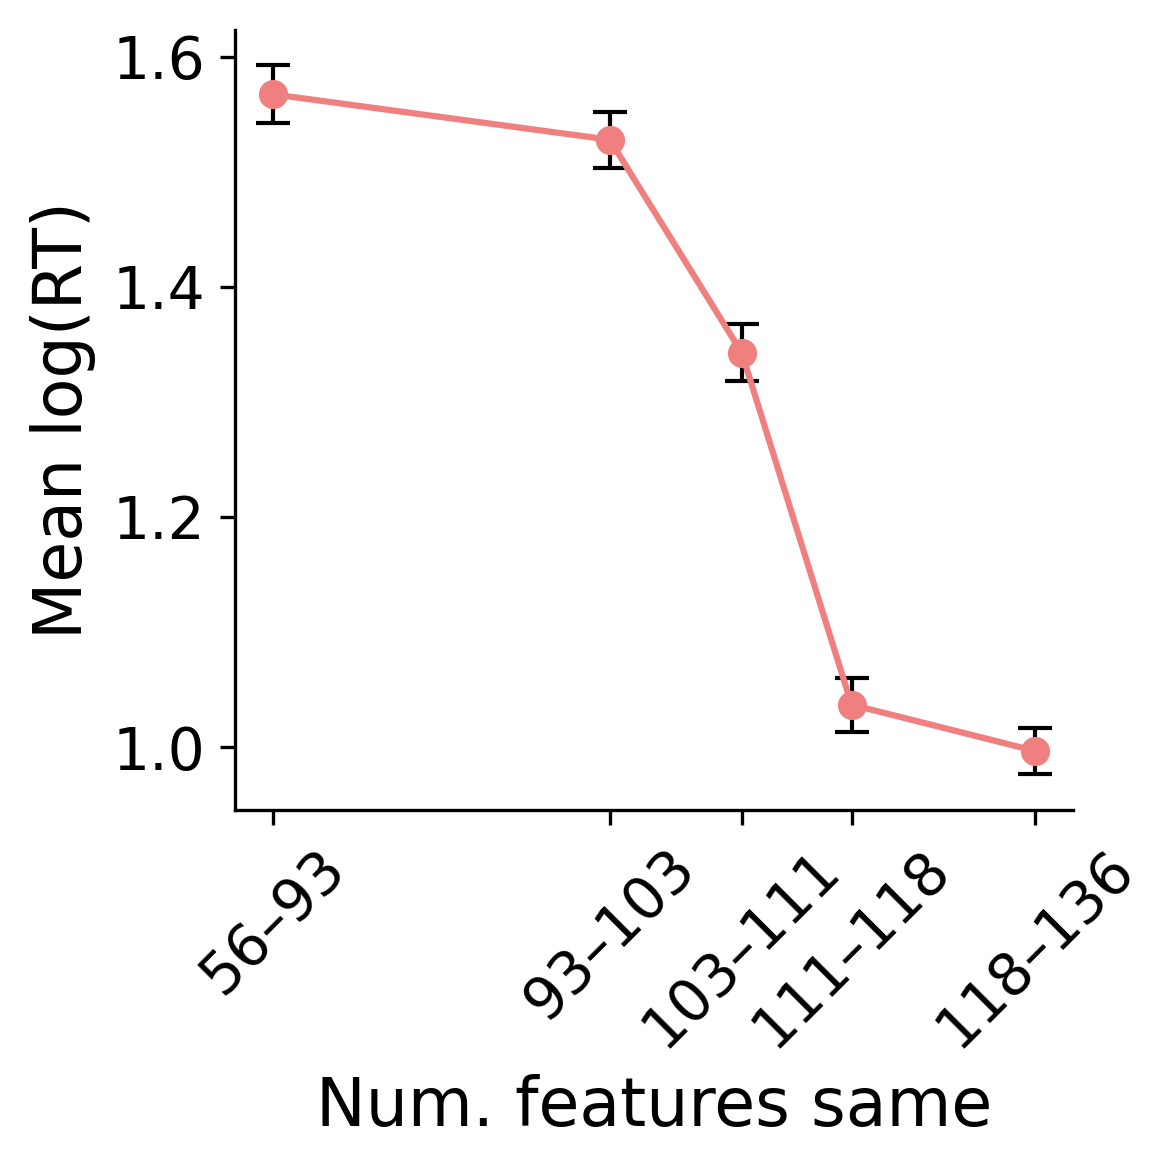

In [13]:
data["bin"] = pd.qcut(data["num_features_same"], q=5)
group_stats = data.groupby("bin")["logRT"].agg(['mean', 'sem']).reset_index()
x_positions = [ (interval.left + interval.right) / 2 for interval in group_stats["bin"] ]
bin_labels = [f"{int(interval.left)}–{int(interval.right)}" for interval in group_stats["bin"]]
plt.figure(figsize=(4, 4))
plt.errorbar(x_positions, group_stats["mean"], yerr=group_stats["sem"], fmt='o-', color='lightcoral', ecolor='black', elinewidth=1, capsize=4)
plt.xticks(ticks=x_positions, labels=bin_labels, rotation=45)
plt.xlabel("Num. features same")
plt.ylabel("Mean log(RT)")
plt.tight_layout()
plt.savefig(base_path + "plots/Figure2/2C.pdf")
plt.show();

## Figure 2D

In [14]:
new_cols = {}
for col in feature_cols:
    new_col = f"{col}_switch"
    tmp = (data.groupby('pid')[col].transform(lambda x: (x != x.shift()).astype(int)))
    tmp.loc[data.groupby('pid').head(1).index] = np.nan
    new_cols[new_col] = tmp
data = pd.concat([data, pd.DataFrame(new_cols, index=data.index)], axis=1)

diff_dict = {}
for col in feature_cols:
    bin_col = f"{col}_switch"
    temp = data.dropna(subset=[bin_col])
    logrt_diff = temp.groupby('pid').apply(lambda g: g.loc[g[bin_col] == 1, 'logRT'].mean() - g.loc[g[bin_col] == 0, 'logRT'].mean(), include_groups=False)  # Compute logRT difference per pid
    diff_dict[col] = logrt_diff
diff_df = pd.DataFrame(diff_dict)

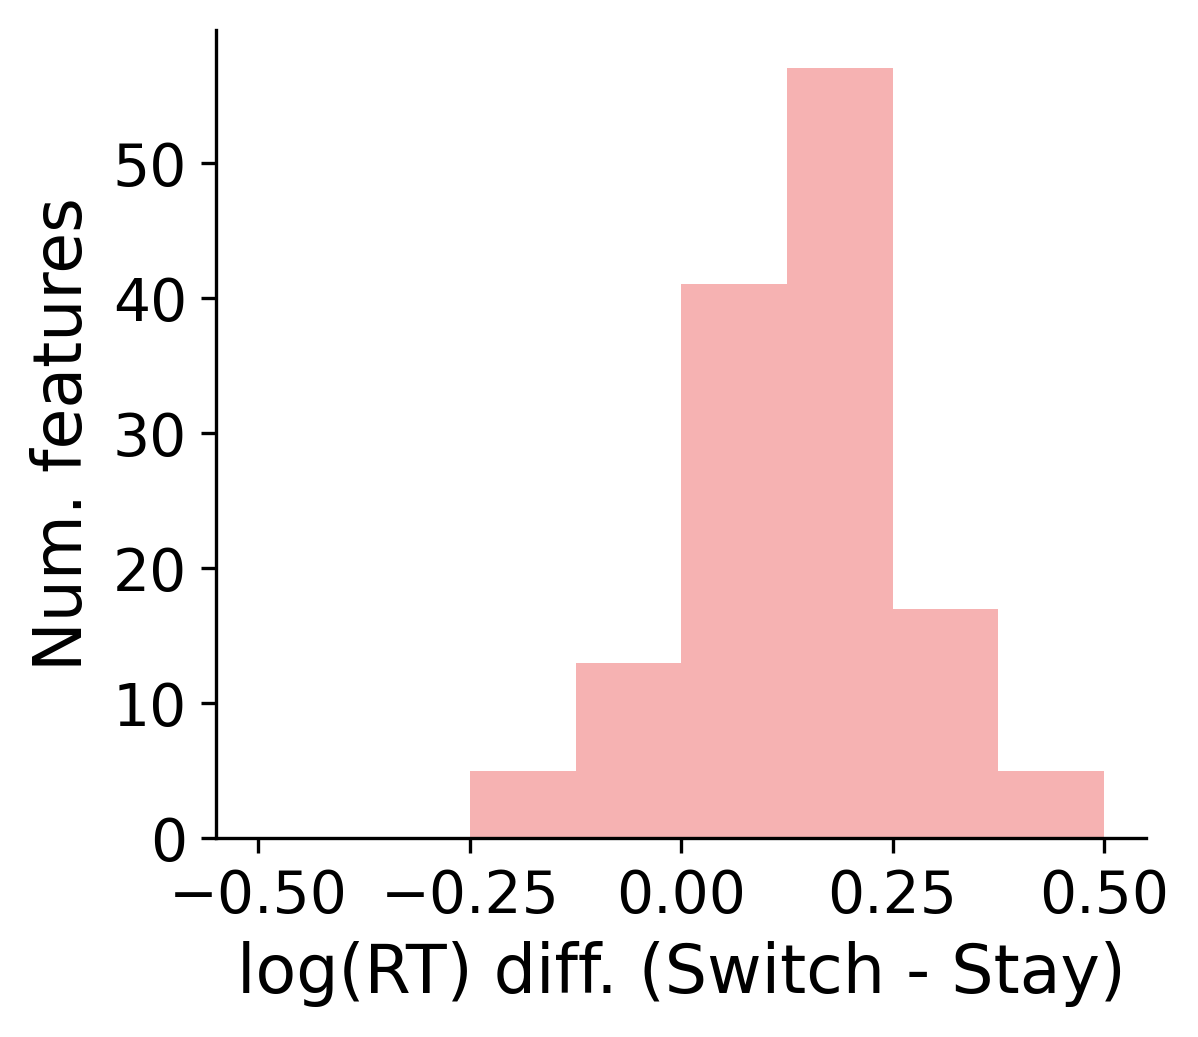

In [ ]:
bin_edges = [-0.5, -0.375, -0.25, -0.125, 0, 0.125, 0.25, 0.375, 0.5]

plt.figure(figsize=(4,3.5))
plt.hist(diff_df.mean(axis=0).values,
         bins=bin_edges,
         color="lightcoral",
         alpha=0.6)

plt.ylabel("Num. features")
plt.xlabel("log(RT) diff. (Switch - Stay)")
plt.savefig(base_path + "plots/Figure2/2D.pdf", bbox_inches="tight")

# Figure 2E

In [16]:
num_simulations = 100

# Uniform
sum_activity_diff1 = []
pid_to_count = data.groupby("pid")["response"].count().to_dict()
unique_responses = data["response"].unique()
for i in range(num_simulations):
    data_simulatedrandom = pd.DataFrame(columns=["pid", "response"])
    for pid, count in pid_to_count.items():
        sampled_responses = np.random.choice(unique_responses, size=count, replace=False)
        temp_df = pd.DataFrame({
            "pid": [pid] * count,
            "response": sampled_responses
        })
        data_simulatedrandom = pd.concat([data_simulatedrandom, temp_df], ignore_index=True)
    data_simulatedrandom, dropped_rows2_simulatedrandom = add_features_to_responsedf(data_simulatedrandom)
    sum_abs_mean_activity_diff = sum(np.abs(vf_featuredf[feature_cols].mean() - data_simulatedrandom.groupby("pid")[feature_cols].mean().mean()))
    sum_activity_diff1.append(sum_abs_mean_activity_diff)

In [17]:
# Frequency-based
with open(base_path + "files/freq_abs_log.json", "r") as f:
    freq_abs = json.load(f)
freq_abs = {k: v for k, v in freq_abs.items() if k.replace(" ", "").replace("-", "") in unique_responses}
with open(base_path + "files/response_corrections.json", 'r') as f:
    corrections = json.load(f)
probs = np.array([freq_abs[corrections.get(r, r)] for r in unique_responses])
probs = np.exp(probs)          # convert from log frequencies
probs /= probs.sum()           # normalize to sum to 1
sum_activity_diff2 = []
for i in range(num_simulations):
    data_simulatedrandom = pd.DataFrame(columns=["pid", "response"])
    for pid, count in pid_to_count.items():
        sampled_responses = np.random.choice(unique_responses, size=count, replace=False, p=probs)
        temp_df = pd.DataFrame({
            "pid": [pid] * count,
            "response": sampled_responses
        })
        data_simulatedrandom = pd.concat([data_simulatedrandom, temp_df], ignore_index=True)
    data_simulatedrandom, dropped_rows2_simulatedrandom = add_features_to_responsedf(data_simulatedrandom)
    sum_abs_mean_activity_diff = sum(np.abs(vf_featuredf[feature_cols].mean() - data_simulatedrandom.groupby("pid")[feature_cols].mean().mean()))
    sum_activity_diff2.append(sum_abs_mean_activity_diff)

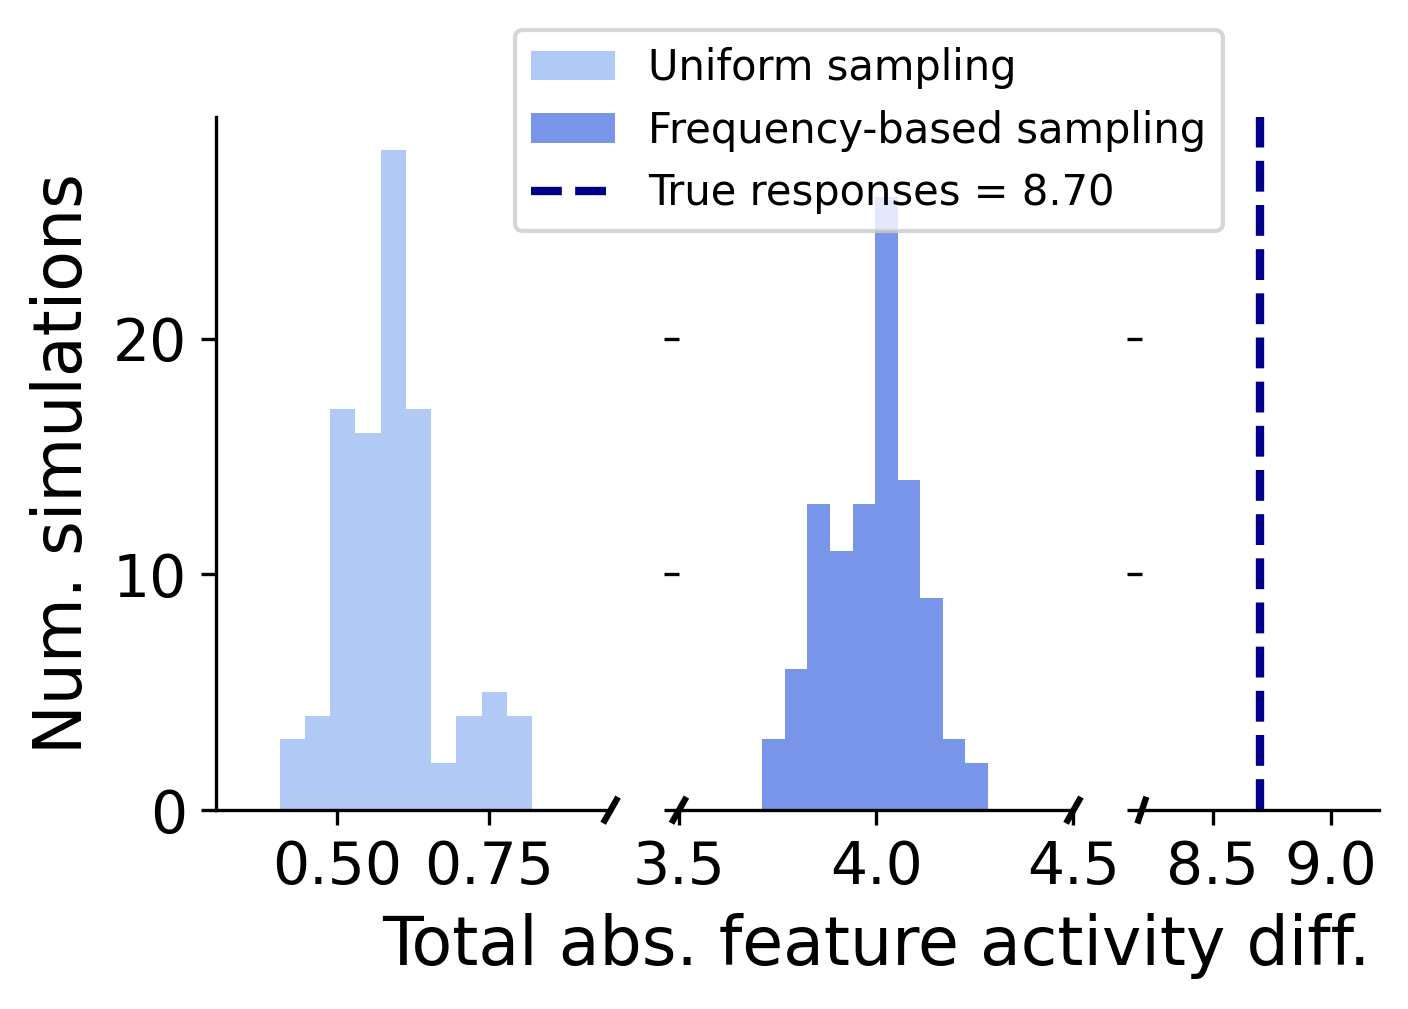

In [18]:
# Plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(5,3), gridspec_kw={'width_ratios': [0.5,0.5,0.3]})
ax1.hist(sum_activity_diff1, alpha=0.5, label='Uniform sampling', color='cornflowerblue')
ax1.set_xlim(0.3, 0.95)
ax1.set_ylabel("Num. simulations")
ax2.hist(sum_activity_diff2, alpha=0.7, label='Frequency-based sampling', color='royalblue')
ax2.set_xlim(3.5, 4.5)
ax2.set_xlabel("Total abs. feature activity diff.")
vline_value = np.sum(np.abs(vf_featuredf[feature_cols].mean() - data.groupby("pid")[feature_cols].mean().mean()))
ax3.axvline(vline_value, color='darkblue', linestyle='--', linewidth=2, label=f'True responses = {vline_value:.2f}')
ax3.set_xlim(vline_value - 0.5, vline_value + 0.5)


for a, b in zip([ax1, ax2], [ax2, ax3]):
    a.spines['right'].set_visible(False)
    b.spines['left'].set_visible(False)

d = 0.015  # size of break slant
def add_break(ax_left, ax_right):
    kwargs = dict(color='k', clip_on=False)
    ax_left.plot((1 - d, 1 + d), (-d, +d), transform=ax_left.transAxes, **kwargs)
    ax_right.plot((-d, +d), (-d, +d), transform=ax_right.transAxes, **kwargs)

add_break(ax1, ax2)
add_break(ax2, ax3)
fig.legend(loc='upper center', bbox_to_anchor=(0.56, 1), ncol=1)
plt.savefig(base_path + "plots/Figure2/2E.pdf")

## Figure 2F

In [19]:
data = datacopy
data["logRT"] = np.log(data["RT"] + 0.001)
data = data[data["logRT"] > -1.6]   # removes RT < 200 ms

In [20]:
rt_activity_influence = []
for feat in vf_featurecols:
    rt0 = data.loc[data[feat] == 0, "logRT"].mean()
    rt1 = data.loc[data[feat] == 1, "logRT"].mean()
    influence = rt0 - rt1
    rt_activity_influence.append(influence)
rt_activity_influence = np.array(rt_activity_influence)

feature_activities = data[vf_featurecols].mean(axis=0).values
pearsr_corr, p_value = scipy.stats.pearsonr(feature_activities, rt_activity_influence)
print(f"Pearson Correlation: {pearsr_corr}, p-value: {p_value}")
sspear_corr, p_value = scipy.stats.spearmanr(feature_activities, rt_activity_influence)
print(f"Spearman Correlation: {sspear_corr}, p-value: {p_value}")

Pearson Correlation: 0.3010445951819365, p-value: 0.00033334249388394376
Spearman Correlation: 0.2643454436486782, p-value: 0.0017300817700412225


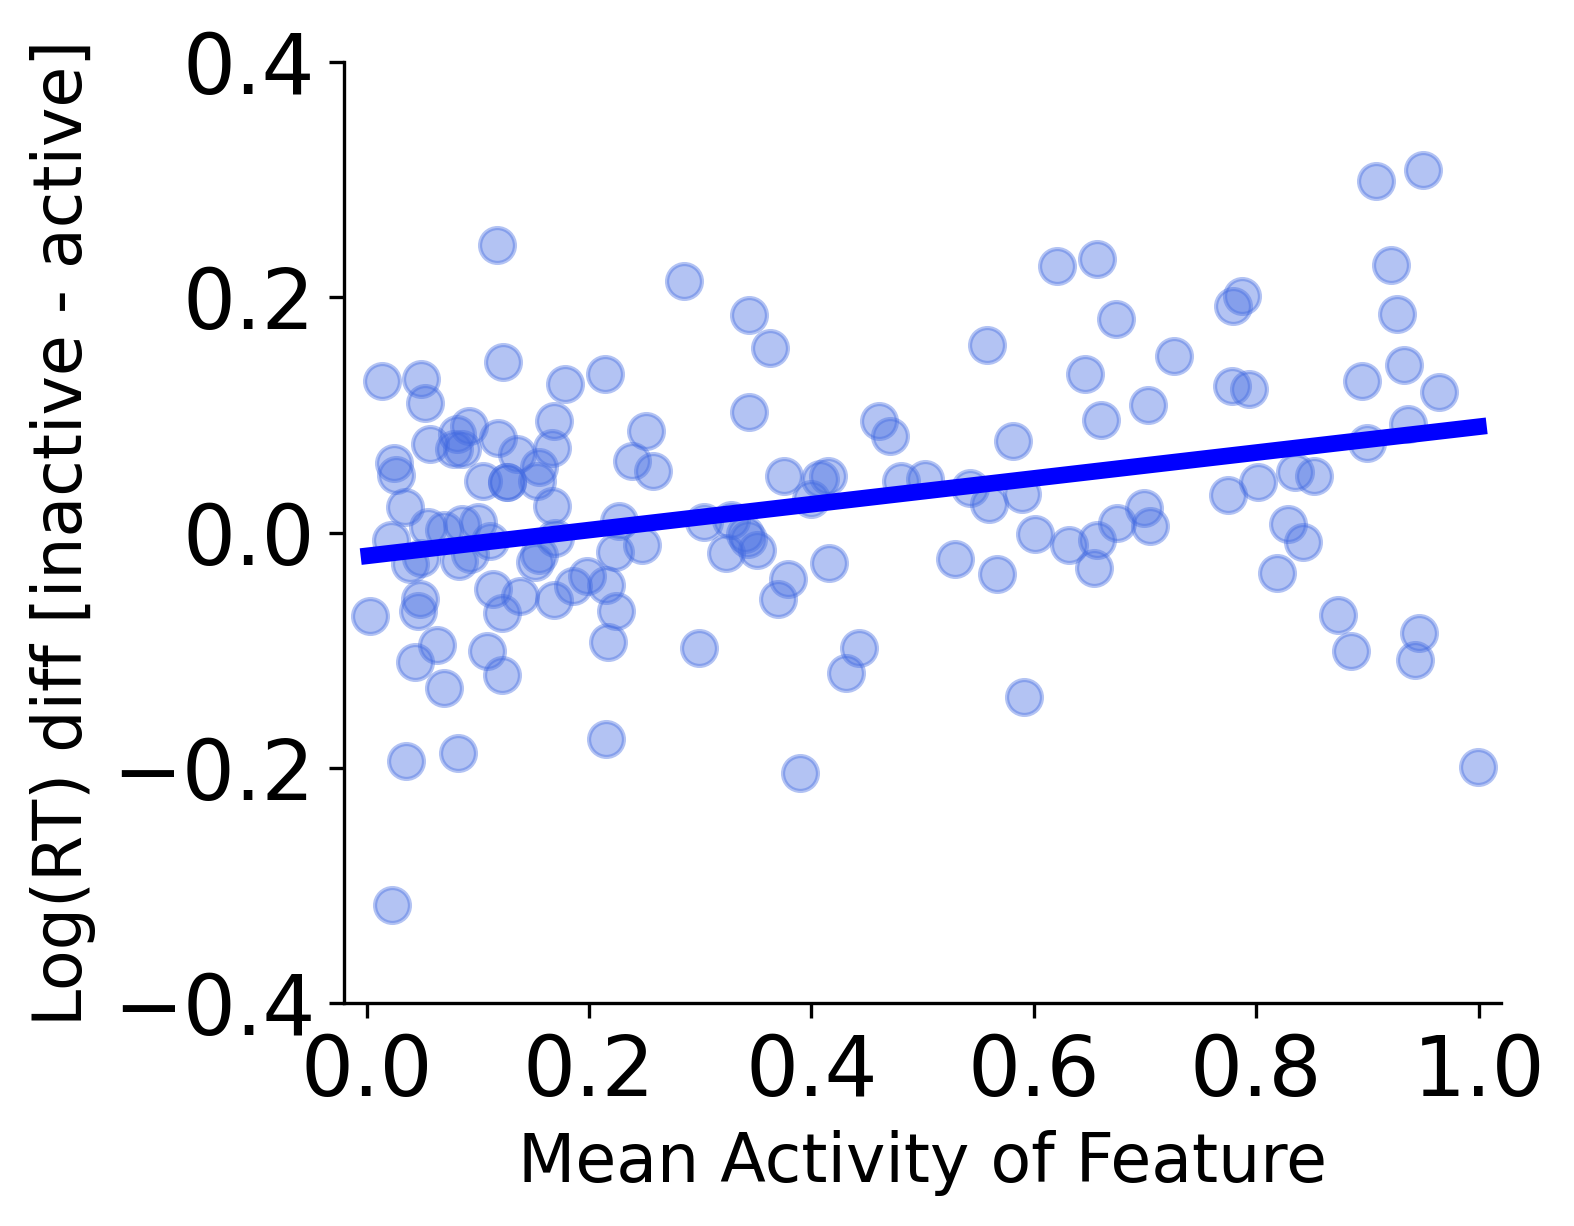

In [21]:
x = np.array(feature_activities)
y = np.array(rt_activity_influence)
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
x_line = np.linspace(x.min(), x.max(), 200)
X_line = sm.add_constant(x_line)
y_line = model.predict(X_line)
plt.figure(figsize=(5,4))
plt.scatter(x, y, color='royalblue', alpha=0.4, s=70)
plt.plot(x_line, y_line, color='blue', linewidth=4)

plt.xlabel("Mean Activity of Feature")
plt.ylabel("Log(RT) diff [inactive - active]")
plt.tight_layout()
plt.xlim(-0.02,1.02)
plt.xticks(fontsize=20)
plt.yticks([-0.4, -0.2, 0, 0.2, 0.4], fontsize=20)
plt.ylim(-0.4, 0.4)
plt.savefig(base_path + "plots/Figure2/2F.pdf", bbox_inches="tight")